In [21]:
SCOPETYPE = 'OPENADC'
PLATFORM = 'CWLITEARM'
CRYPTO_TARGET='NONE' 
SS_VER='SS_VER_1_1'

In [22]:
# Adapt this to your ChipWhisperer installation
%run "../Setup_Scripts/Setup_Generic.ipynb"

INFO: Found ChipWhisperer😍
scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 7864328                   to 29306167                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 0                         to 29538459                 
scope.clock.adc_rate                     changed from 0.0                       to 29538459.0        

In [23]:
samples = 1500
scope.adc.samples = samples

In [24]:
%%bash -s "$PLATFORM" "$CRYPTO_TARGET" "$SS_VER" 
cd target
make clean PLATFORM=$1 CRYPTO_TARGET=$2 SS_VER=$3 -j
make PLATFORM=$1 CRYPTO_TARGET=$2 SS_VER=$3 -j

SS_VER set to SS_VER_1_1
SS_VER set to SS_VER_1_1
rm -f -- MaskedBernoulli-CW308_CC2538.hex MaskedBernoulli-CW301_AVR.hex MaskedBernoulli-CW303.hex MaskedBernoulli-CW304.hex MaskedBernoulli-CW308_MEGARF.hex MaskedBernoulli-CW308_SAM4L.hex MaskedBernoulli-CW308_STM32F0.hex MaskedBernoulli-CW308_STM32F1.hex MaskedBernoulli-CW308_STM32F2.hex MaskedBernoulli-CW308_STM32F3.hex MaskedBernoulli-CW308_STM32F4.hex MaskedBernoulli-CW308_K24F.hex MaskedBernoulli-CW308_NRF52.hex MaskedBernoulli-CW308_AURIX.hex MaskedBernoulli-CW308_SAML11.hex MaskedBernoulli-CW308_EFM32TG11B.hex MaskedBernoulli-CWLITEARM.hex MaskedBernoulli-CWLITEXMEGA.hex MaskedBernoulli-CWNANO.hex MaskedBernoulli-CWHUSKY.hex MaskedBernoulli-CW308_K82F.hex MaskedBernoulli-CW308_PSOC62.hex MaskedBernoulli-CW308_IMXRT1062.hex MaskedBernoulli-CW308_FE310.hex MaskedBernoulli-CW308_EFR32MG21A.hex MaskedBernoulli-CW308_EFM32GG11.hex MaskedBernoulli-CW308_STM32L5.hex MaskedBernoulli-CW308_NEORV32.hex MaskedBernoulli-CW312_SAM4S.hex Mask

In [25]:
cw.program_target(scope, prog, "target/MaskedBernoulli-{}.hex".format(PLATFORM))

Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 19035 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 19035 bytes


In [30]:
from secrets import token_bytes
from random import randint
from tqdm.notebook import trange
from secrets import randbits
import numpy as np

PT_LEN = 32
RESP_LEN = 1

def get_traces(N, print_outputs=False, max_print=25):
    traces_fixed = []
    traces_random = []
    outputs_fixed = []
    outputs_random = []
    
    fixed_sample_seed = bytes([0x42] * 16)

    for i in trange(N, desc='Capturing traces'):
        scope.arm()

        is_fixed = bool(randbits(1)) # randomly choose fixed or random class

        if is_fixed:
            sample_seed = fixed_sample_seed
        else:
            sample_seed = token_bytes(16)

        mask_seed = token_bytes(16) # fresh, independent masking randomness

        pt = bytearray(sample_seed + mask_seed)
        assert len(pt) == PT_LEN

        target.simpleserial_write('p', pt)

        ret = scope.capture()
        t = scope.adc.trig_count

        if ret:
            print("Target timed out!")
            continue

        response = target.simpleserial_read('r', RESP_LEN)
        if response is None or len(response) != RESP_LEN:
            print("Invalid response:", response)
            continue

        trace = scope.get_last_trace()
        out = int(response[0])
        
        if is_fixed:
            traces_fixed.append(trace)
            outputs_fixed.append(out)
        else:
            traces_random.append(trace)
            outputs_random.append(out)

    size = min(len(traces_fixed), len(traces_random))

    traces_fixed = traces_fixed[:size]
    traces_random = traces_random[:size]
    outputs_fixed = outputs_fixed[:size]
    outputs_random = outputs_random[:size]

    if print_outputs:
        print("Fixed outputs, first", min(max_print, len(outputs_fixed)), ":")
        print(outputs_fixed[:max_print])

        print("Random outputs, first", min(max_print, len(outputs_random)), ":")
        print(outputs_random[:max_print])
    
    print("Trigger up for", t, "ADC cycles")
    return (traces_fixed[:size], traces_random[:size])

In [31]:
ch = 0
if ch == 0:
    VERBOSE = False
    nb_traces = 200000
    traces_1, traces_2 = get_traces(nb_traces)
else:
    VERBOSE = True
    nb_traces = 100
    traces_1, traces_2 = get_traces(nb_traces)

Capturing traces:   0%|          | 0/200000 [00:00<?, ?it/s]

Trigger up for 1460 ADC cycles


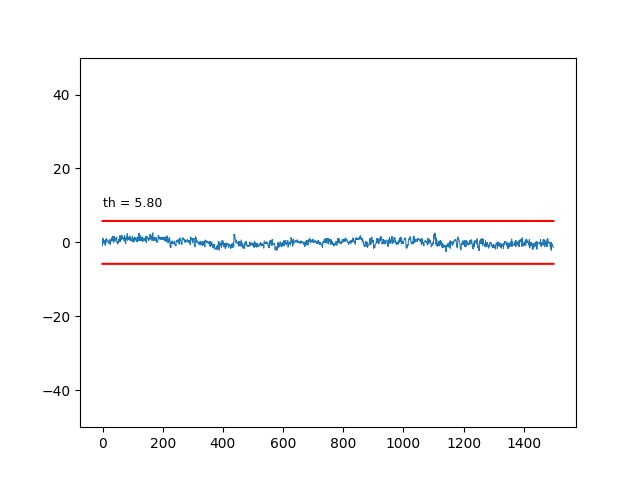

In [32]:
%matplotlib ipympl
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
from scipy.stats import norm

alpha = 10**(-5) # error rate
sigma = 1 - (1 - alpha)**(1/samples)
th = norm.ppf(1 - sigma/2) # we adapt the threshold depending on number of samples
t_val = ttest_ind(traces_1, traces_2, axis=0, equal_var=False)[0]
plt.close()
plt.plot(t_val[0:], linewidth=0.75)
plt.plot([th]*scope.adc.samples, color = 'r')
plt.plot([-th]*scope.adc.samples, color='r')
y_offset = 0.5 * th  
plt.text(
    2,                  
    th + y_offset,
    f"th = {th:.2f}",
    color='black',
    fontsize=9,
    verticalalignment='bottom'
)
plt.ylim(-50, 50)
plt.show()

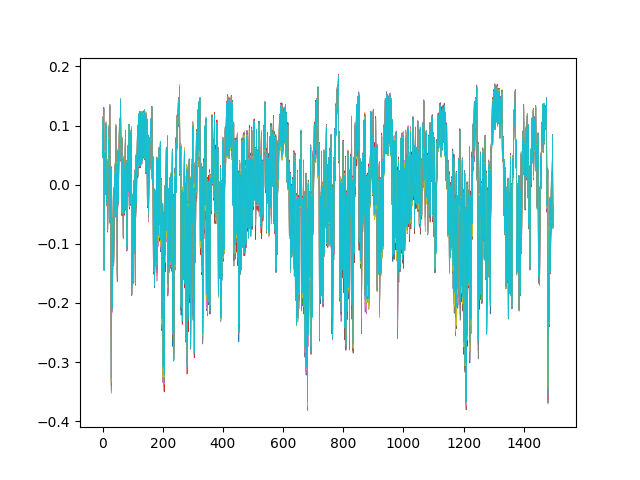

In [33]:
%matplotlib ipympl
import matplotlib.pyplot as plt

plt.close()
for t in traces_1[:10]:
    plt.plot(t[:], linewidth=0.5)
plt.show()

In [34]:
target.dis()
scope.dis()

True